This star: sk6718 has already been flagged.
sk6718:----------------1/434--------------------


/usr/local/python-3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


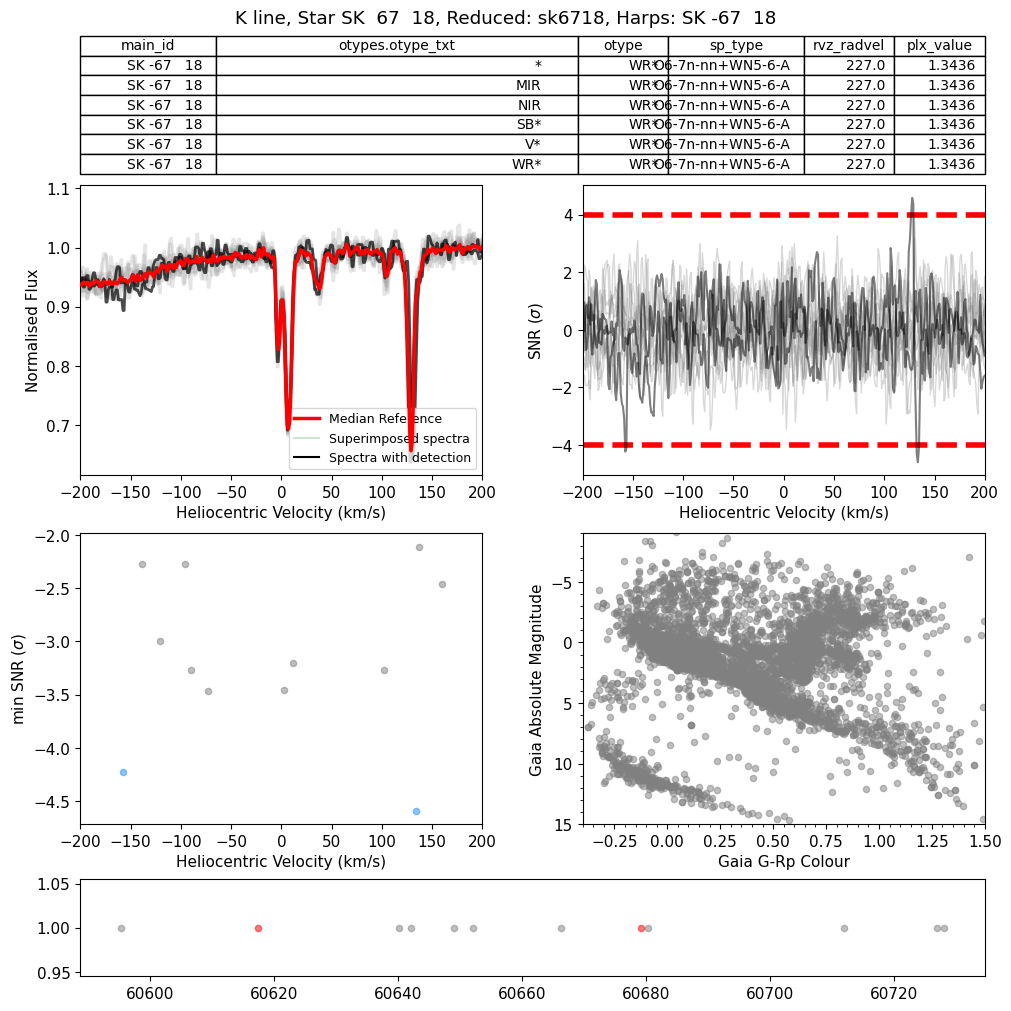


Classify sk6718 — y=candidate | n=not cand (real) | j=junk | w=flag | s=skip | q=save | x=quit+save | d=print df | o=print detections
sk6718: SKIPPED
hd323771:----------------2/434--------------------


/usr/local/python-3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


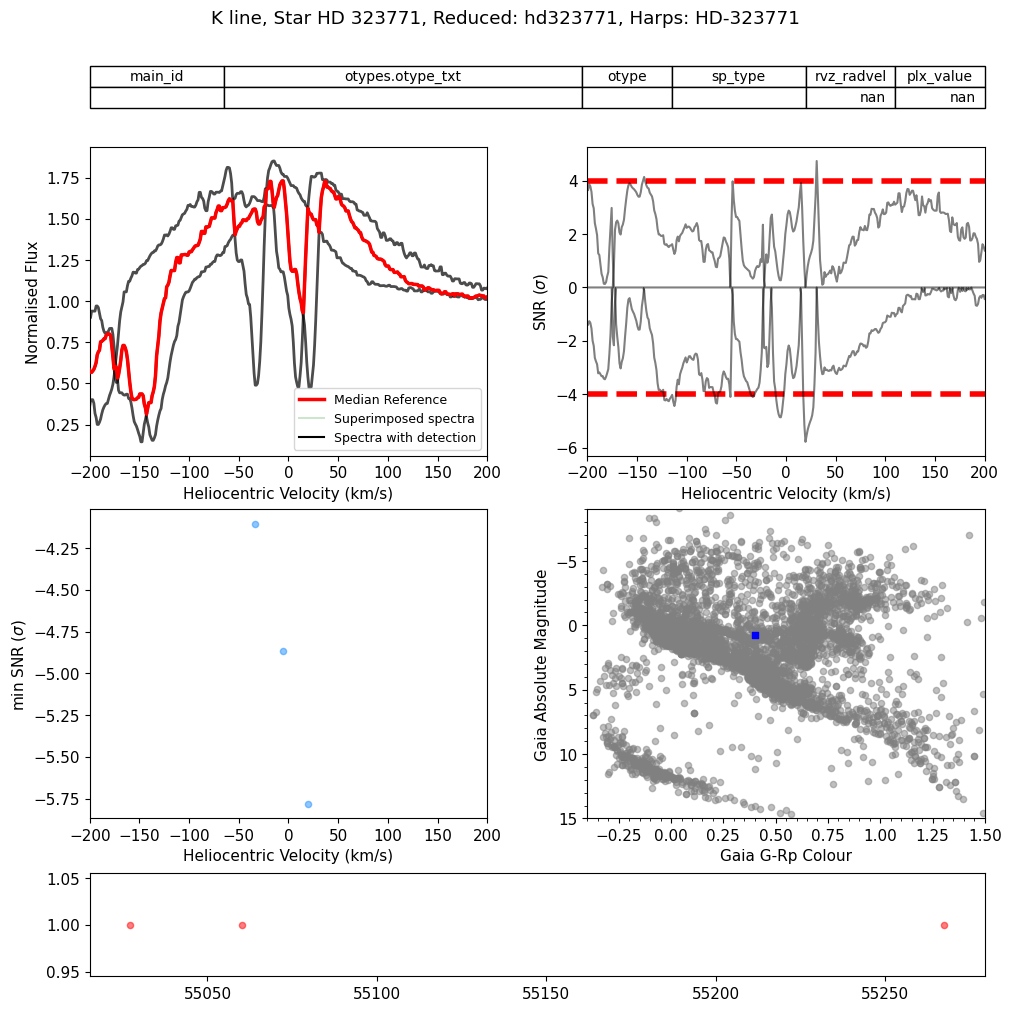


Classify hd323771 — y=candidate | n=not cand (real) | j=junk | w=flag | s=skip | q=save | x=quit+save | d=print df | o=print detections
hd323771: SKIPPED
vssleo:----------------3/434--------------------


/usr/local/python-3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


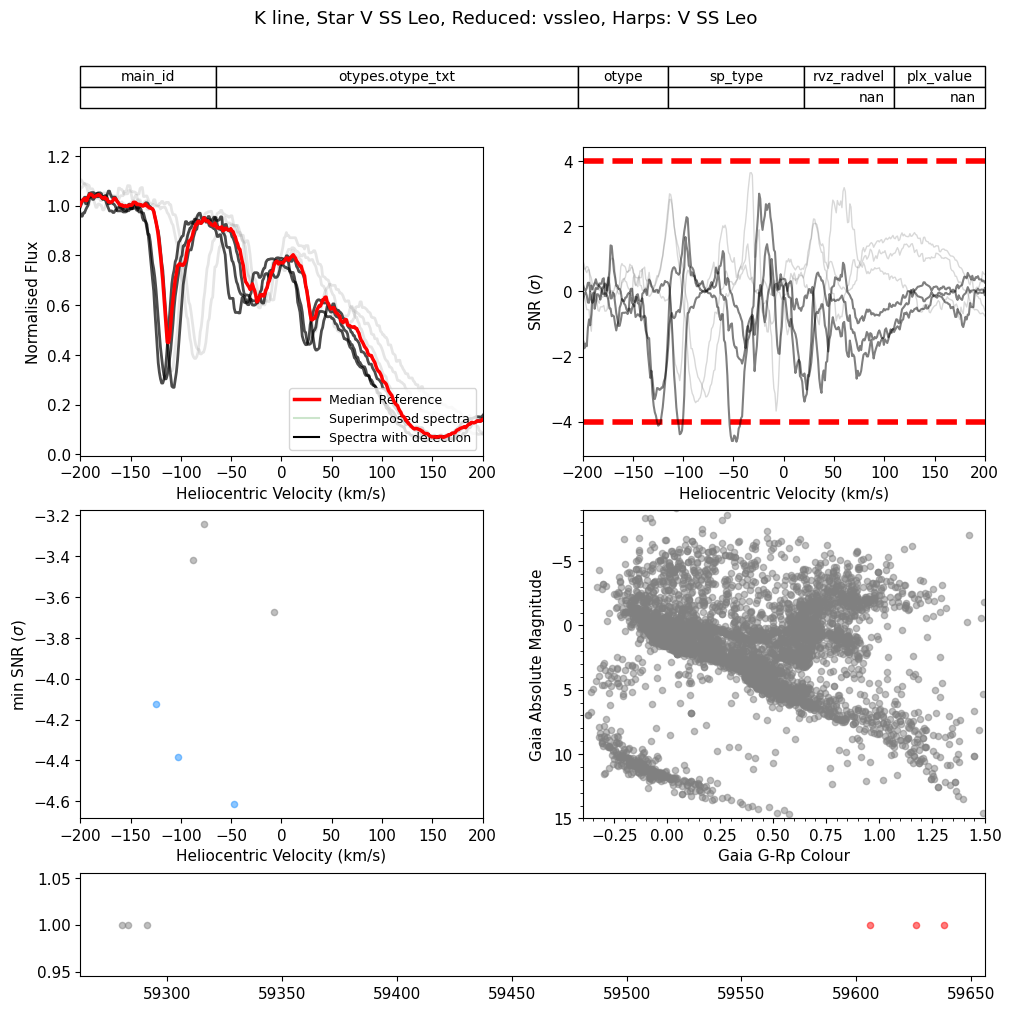


Classify vssleo — y=candidate | n=not cand (real) | j=junk | w=flag | s=skip | q=save | x=quit+save | d=print df | o=print detections
vssleo: SKIPPED
hd168076:----------------4/434--------------------


KeyboardInterrupt: 

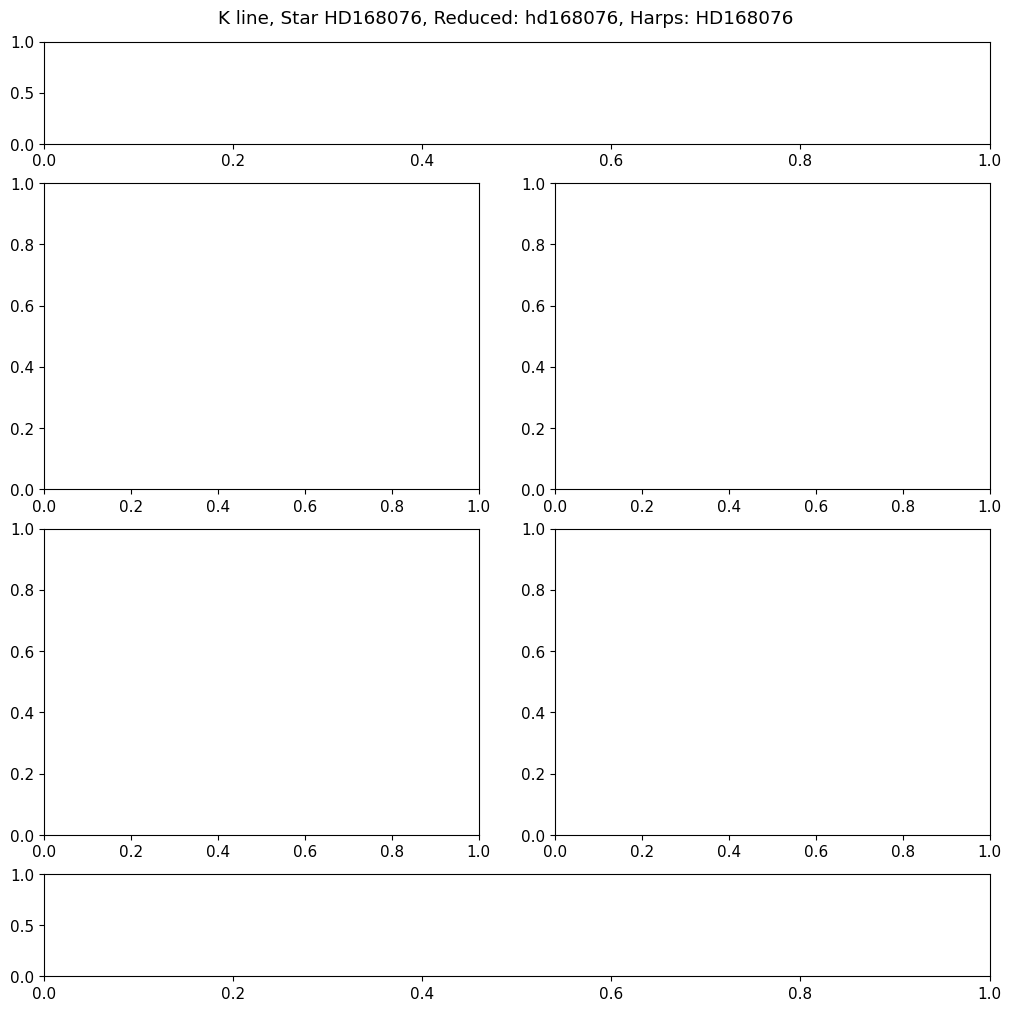

In [2]:
import pandas as pd
pd.set_option("display.max_rows", 50)

import numpy as np
import os, sys
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = "11"

from statistics import mode
from matplotlib.ticker import AutoMinorLocator
# import multiprocessing
import json, argparse

%run ./asset.ipynb
%run ./otypes.ipynb
%run ./reduce_name.ipynb
%run ./match_name.ipynb
%run ./HR.ipynb
%run ./classifier.ipynb

parser = argparse.ArgumentParser(description='Automatic Spectroscopy Search for Exocomet Transits Tutorial', epilog='ASSET by RBW', allow_abbrev=False)
parser.add_argument('--p', metavar='param.json', default='param.json', help='parameter file name (default:input_param.json)')
parser.add_argument('--star', metavar='star', default='None', help='Individual star you want to look at')
parser.add_argument('--force', metavar='force_star', default='None', help='Force star you want to look at - input dataset name')
parser.add_argument('--nice', metavar='niceness', default=15, help='niceness of job (default: 15)')
parser.add_argument('--line', metavar='line', default='K', help='define what atomic line to use (default: "K")')
parser.add_argument('--cands', metavar='review_cands', default='False', help='review previously flagged as candidates (default: False)')
parser.add_argument('--r', metavar='res-path', default='../results/CandidateReport/', help='path for candidate report (default: CandidateReport/)')
parser.add_argument('--idir', metavar='input-path', default='../results/QuickSearch/', help='path for numpy list of candidates from quicksearch.py (default: QuickSearch/)')
parser.add_argument('--savefig', metavar='fig-path', default='None', help='path to save plots when running iplotter.py just for plots (default: None)')
args, _ = parser.parse_known_args()

os.nice(int(args.nice))

with open(args.p) as paramfile:
    param = json.load(paramfile)

if str(args.star) != 'None':
    target = to_reduce(str(args.star))
    try:
        cand_info = find_target(target)
        candidates = [cand_info.Reduced]
        print('The star {} is observed by UVES.'.format(cand_info.Sanitised))
        single_star = True
    except FileNotFoundError:
        print('The star {} ({}) does not exist. Try again!'.format(str(args.star), target))
        sys.exit()
elif str(args.force) != 'None':
    candidates = [str(args.force)]
    single_star = True
else:
    # Input candidate list
    if str(args.cands) == 'False':
        candidates = np.load(args.idir + 'candidates_{}sig_{}cut_{}width.npy'.format(param["threshold"], param["cutoff"], param["width_filt"]), allow_pickle = True)
    else:
        # review_cands = True
        # TODO load candidate numpy array
        candidate_report = pd.read_pickle(args.r + 'candidate_report.pkl')
        all_candidates = candidate_report[candidate_report.Status == 'candidate']
        candidates = all_candidates.Target.to_numpy()
    # candidates = np.array(['hd172555', 'betapic', 'hr7596', 'hr4502', 'hr3702'])
    
    single_star = False

# old_report = pd.read_pickle('CandidateReport/old_candidate_report.pkl')
# newest_report = pd.read_pickle('CandidateReport2/candidate_report.pkl')

if not os.path.exists(args.r):
    os.makedirs(args.r)
    print("new directory {} created!".format(args.r))

Search = ASSET(parameters = param, line=args.line)
HRd = HR_Diagram()
Classifier = Classify(param, args.r)

review_flagged = True

while review_flagged == True:
    look_flagged = None # Flag to note if user wants to review flagged targets
    review_skipped = True

    while review_skipped == True:

        look_skip = None # Flag to note if user wants to review skipped targets
        
        for i,cand in enumerate(candidates):

            plot = False
            Search.ccf = False

            classified = Classifier.candidate_info(cand)
            
            if classified:
                if str(args.savefig) != 'None':
                    print('This star: {} has been classified as {}.'.format(cand, Classifier.previous_report.Status.to_numpy()[0]))

                elif Classifier.flagged:
                    print('This star: {} has already been flagged.'.format(cand))
                elif single_star == True:
                    print('This star: {} has already been classified as {}.'.format(cand, Classifier.previous_report.Status.to_numpy()[0]))
                else:
                    continue
            print('{}:----------------{}/{}--------------------'.format(cand,i+1, len(candidates)))

            star_path = param["dataset"] + '{}/'.format(cand)
            spec_param = Search.spec_analysis(star_path)

            if spec_param == None:
                if single_star == True:
                    print('{}: Not enough spectra for the search to be completed.'.format(cand))
                    sys.exit()
                else:
                    continue
            else:
                new_spectra, med, med_err = spec_param
                ref_spec = med[Search.snr_idxrange]

                corr_med = med.copy()
                if Search.ccf == True:
                    rv_shift = Search.X_corr(corr_med)
                    cond100 = (Search.radial_velocity > rv_shift-50) & (Search.radial_velocity < rv_shift+50)
                    corr_med[cond100] = np.nan

                Classifier.target_info = Search.df            

            # Determine which date column is available
            date_col = 'MJD-OBS' if 'MJD-OBS' in Classifier.target_info.columns else 'Date'

            while Classifier.current_status == None:

                fig = plt.figure(constrained_layout=True, figsize=(10,10))

                gs = GridSpec(8, 2, figure=fig)
                ax1 = fig.add_subplot(gs[0, :]) # otype search dataframe

                ax2 = fig.add_subplot(gs[1:4, 0]) # spec with detection from search
                ax3 = fig.add_subplot(gs[1:4, 1], sharex = ax2) # snr from search

                ax4 = fig.add_subplot(gs[4:7, 0], sharex = ax2) # min snr vs rv position
                ax5 = fig.add_subplot(gs[4:7, 1]) # HR diagram full

                ax6 = fig.add_subplot(gs[7, :])

                fig.suptitle("{} line, Star {}, Reduced: {}, Harps: {}".format(args.line, Search.target_san, Search.target_red, Search.target_harps))
                
                simbad_search = get_otypes(Search.target_harps)

                ax1.axis('off')
                try:
                    table = ax1.table(cellText=simbad_search.values,colLabels=simbad_search.columns,loc='center', colWidths=[0.15, 0.4, 0.1, 0.15, 0.1, 0.1])
                    table.auto_set_font_size(False)
                    table.set_fontsize(10)
                except:
                    ax1.text(0.5, 0.5, 'No match with Simbad')

                ax2.set_ylabel('Normalised Flux')
                ax2.set_xlabel('Heliocentric Velocity (km/s)')
                ax2.set_xlim(Search.rv_min,Search.rv_max)

                ax3.set_ylabel('SNR ($\sigma$)')
                ax3.set_xlabel('Heliocentric Velocity (km/s)')
                ax3.hlines(-1 * Search.threshold, Search.rv_min,Search.rv_max, linestyles= 'dashed', linewidth=4, colors='red')
                ax3.hlines(1 * Search.threshold, Search.rv_min,Search.rv_max, linestyles= 'dashed', linewidth=4, colors='red')

                ax4.set_ylabel('min SNR ($\sigma$)')
                ax4.set_xlabel('Heliocentric Velocity (km/s)')

                all_gaia_colours, all_gaia_Mag = HRd.build_HR(HRd.gaia_xmatch, adjust=False)
                target_gaia_info = HRd.get_star_gaia_info(Search.target_red)
                target_gaia_colours, target_gaia_Mag = HRd.build_HR(target_gaia_info, adjust = False)

                ax5.scatter(all_gaia_colours, all_gaia_Mag, s=20, marker = 'o', color = 'grey', alpha = 0.5)
                ax5.scatter(target_gaia_colours, target_gaia_Mag, s=20, marker = 's', color = 'blue')

                ax5.set_ylabel('Gaia Absolute Magnitude')
                ax5.set_xlabel('Gaia G-Rp Colour')
                ax5.set_xlim((-0.4, 1.5))
                ax5.set_ylim((-9,15))
                ax5.invert_yaxis()
                ax5.yaxis.set_minor_locator(AutoMinorLocator())
                ax5.xaxis.set_minor_locator(AutoMinorLocator())

                indices = []
                all_min_SNR = []
                all_rv_pos = []
                all_width = []
                all_abs_depth = []

                for i in range(len(new_spectra)):

                    detection = False

                    spec = new_spectra[i]

                    corr_spec = spec.copy()
                    if Search.ccf:
                        corr_spec[cond100] = np.nan

                    filtered_spec = spec[Search.snr_idxrange]
                    snr = Search.snr(spec, med, Search.spectra_err[i], med_err)
                        
                    sd = np.std(snr)

                    corr_snr = snr.copy()
                    if Search.ccf == True:
                        corr_snr[cond100] = np.nan

                    corr_snr = corr_snr[Search.snr_idxrange]

                    sig = corr_snr/sd

                    min_detect = np.nanmin(sig)
                    all_min_SNR.append(round(min_detect,2))

                    filtered_rv = Search.radial_velocity[Search.snr_idxrange]
                    rv_detect = filtered_rv[sig == min_detect][0]
                    all_rv_pos.append(round(rv_detect,2))

                    if min_detect < Search.threshold:
                        width = Search.get_width(sig)
                        
                        if width >= Search.width_filter:
                            plot = True
                            detection = True

                            indices.append(i)
                            all_width.append(width)

                            abs_depth = (ref_spec[filtered_rv == rv_detect] - filtered_spec[filtered_rv == rv_detect])/ref_spec[filtered_rv == rv_detect]
                            all_abs_depth.append(round(abs_depth[0],2))

                            ax2.plot(Search.radial_velocity, corr_spec, linewidth = 2,alpha = 0.7, 
                                                    color ='k', zorder= 5)

                            ax3.plot(filtered_rv, sig, linewidth =1.5,color = 'k', alpha= 0.5, zorder = 5)

                            ax4.scatter(rv_detect, min_detect, s=20, marker = 'o', color = 'dodgerblue', alpha = 0.5)
                            ax6.scatter(Classifier.target_info.loc[i , date_col], 1, s=20, marker = 'o', color = 'red', 
                                        zorder = 5, alpha = 0.5)

                    if detection == False:
                        ax4.scatter(rv_detect, min_detect, s=20, marker = 'o', color = 'grey', alpha = 0.5)
                        ax2.plot(Search.radial_velocity, corr_spec, linewidth = 2,alpha = 0.2, color ='grey', zorder = 0)
                        ax6.scatter(Classifier.target_info.loc[i , date_col], 1, s=20, marker = 'o', color = 'grey', 
                                    zorder = 0, alpha = 0.5)
                        ax3.plot(filtered_rv, sig, linewidth =1,color = 'grey', alpha= 0.3, zorder = 0)
    
                ax2.plot(Search.radial_velocity, corr_med, linewidth = 2.5,color = 'r', label='Median Reference', zorder = 10)
                if Search.ccf:
                    ax2.plot(Search.radial_velocity, med, linewidth = 2.5,color = 'r', linestyle = '--', alpha =0.2, label='Original Median Reference', zorder = 0)
                
                handles, labels = ax2.get_legend_handles_labels()
                spectra_legend = Line2D([0], [0], label='Superimposed spectra', color='g', alpha=0.2)
                spectra_det_legend = Line2D([0], [0], label='Spectra with detection', color='k')
                handles.extend([spectra_legend, spectra_det_legend])
                ax2.legend(handles=handles, loc='lower right', fontsize=9)

                Classifier.target_info['Min_SNR'] = all_min_SNR
                Classifier.target_info['RV_pos'] = all_rv_pos
                Classifier.detection_info = Classifier.target_info.iloc[indices].copy()
                Classifier.detection_info['Abs_width'] = all_width
                Classifier.detection_info['Abs_depth'] = all_abs_depth

                if plot == True:

                    if str(args.savefig) != 'None':
                        plt.savefig(args.savefig + '{}.png'.format(cand), bbox_inches = 'tight', dpi=150)
                        print(cand, 'saved!')
                        Classifier.current_status = 'saved'
                        plt.close(fig)
                        continue

                    plt.show()
                    Classifier.ask_user()

                else:
                    if single_star == True:
                        print('{}: No detection for this star.'.format(cand))
                        plt.show()
                        Classifier.current_status = 'plotted'
                    else:
                        plt.close(fig)
                        Classifier.current_status = 'skipped'

            if single_star == True:
                sys.exit()
                
            if str(args.savefig) != 'None':
                continue

            save_path = Classifier.classify()

            if save_path != None:
                print('{}: Saving fig...'.format(Search.target_red))
                fig.savefig(save_path + '{}.png'.format(Search.target_red), dpi=150)
                print('{}: Saved fig!'.format(Search.target_red))
            
            plt.close(fig)

        if str(args.savefig) != 'None':
            sys.exit()

        if len(Classifier.skipped) >= 1:
            while (look_skip != 'y') & (look_skip != 'n'):
                look_skip = input('Do you want to review Skipped targets? (y/n) ')
                if look_skip == 'y':
                    review_skipped = True
                    candidates = Classifier.skipped
                    Classifier.skipped = []
                elif look_skip == 'n':
                    review_skipped = False
                    Classifier.skipped = []
                else:
                    print('Answer not recorded. Try again.')
        else:
            review_skipped = False

    # If there are any flagged targets
    if len(Classifier.candidate_report.Target[Classifier.candidate_report.Status == 'flagged'].to_numpy()) >= 1:
        while (look_flagged != 'y') & (look_flagged != 'n'):
            look_flagged = input('Do you want to review Flagged targets? (y/n) ')
            if look_flagged == 'y':
                review_flagged = True
                candidates = Classifier.candidate_report.Target[Classifier.candidate_report.Status == 'flagged'].to_numpy()
            elif look_flagged == 'n':
                review_flagged = False
            else:
                print('Answer not recorded. Try again.')
    else:
        review_flagged = False

print('All stars have been looked at.')
print('Saving progress...')
Classifier.candidate_report.to_pickle(Classifier.cand_report_path)
Classifier.candidate_report.to_html(Classifier.res_path + 'Report.html')
print('Saved!')
